# NLP project
this project Classifys text as 'AI-generated' or 'Human-written' using the `df` DataFrame by applying text preprocessing, splitting the data into training and testing sets, vectorizing the text using Bag-of-Words, training and evaluating both Multinomial Naive Bayes and Logistic Regression models, comparing their performance with visualizations, and creating a function to predict the category of new, unseen text, finally summarizing the findings.

In [32]:
# What this cell does: Imports necessary libraries for text preprocessing and downloads NLTK data.
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data if not already downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("NLTK libraries imported and data downloaded successfully.")

NLTK libraries imported and data downloaded successfully.


In [33]:
# What this cell does: Downloads the dataset using kagglehub.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denvermagtibay/ai-generated-essays-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-generated-essays-dataset' dataset.
Path to dataset files: /kaggle/input/ai-generated-essays-dataset


In [34]:
# What this cell does: Lists the contents of the downloaded dataset directory.
import os

# List contents of the downloaded dataset directory
dataset_path = path # Corrected path to use the downloaded dataset location
print(os.listdir(dataset_path))

['AI Generated Essays Dataset.csv']


In [35]:
# What this cell does: Loads the CSV dataset into a pandas DataFrame and displays its head.
import pandas as pd
import os

# Define the path to the dataset file
dataset_file_path = os.path.join(dataset_path, 'AI Generated Essays Dataset.csv')

# Load the dataset into a DataFrame
df = pd.read_csv(dataset_file_path)

print("Dataset 'AI Generated Essays Dataset.csv' loaded successfully:")
display(df.head())

Dataset 'AI Generated Essays Dataset.csv' loaded successfully:


,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


## Text Preprocessing


Apply a full preprocessing pipeline to the 'text' column of the DataFrame. This includes lowercasing, removing numbers, removing punctuation, removing stopwords, tokenization, and lemmatization.


In [36]:
# What this cell does: Defines a text cleaning function and applies it to the DataFrame's 'text' column.
#text preprocessing
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import string
import nltk

# Ensure NLTK data is downloaded (if not already handled in setup)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Load stopwords list
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Clean a single text string:
    - Convert to lowercase
    - Remove URLs, HTML, punctuation, numbers
    - Fix hyphenated words
    - Tokenize, remove stopwords, and lemmatize
    """

    # ---- Lowercase ----
    text = text.lower()

    # ---- Replace hyphens with space (fixes “decision-making”) ----
    text = text.replace("-", " ")

    # ---- Remove URLs & HTML ----
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # ---- Remove punctuation ----
    text = text.translate(str.maketrans("", "", string.punctuation))

    # ---- Remove digits ----
    text = re.sub(r"\d+", " ", text)

    # ---- Normalize whitespace ----
    text = re.sub(r"\s+", " ", text).strip()

    # ---- Tokenize ----
    tokens = word_tokenize(text)

    # ---- Remove stopwords ----
    tokens = [tok for tok in tokens if tok not in stop_words]

    # ---- Lemmatize ----
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    # Join tokens back to single cleaned string
    return " ".join(tokens)

# Apply improved cleaning to dataset
df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("Text preprocessing complete. A new column 'clean_text' has been added to the DataFrame.")
print(df[['text', 'clean_text']].head())

Text preprocessing complete. A new column 'clean_text' has been added to the DataFrame.
                                                text  \
0  Machine learning, a subset of artificial intel...   
1  A decision tree, a prominent machine learning ...   
2  Education, a cornerstone of societal progress,...   
3  Computers, the backbone of modern technology, ...   
4  Chess, a timeless game of strategy and intelle...   

                                          clean_text  
0  machine learning subset artificial intelligenc...  
1  decision tree prominent machine learning algor...  
2  education cornerstone societal progress extend...  
3  computer backbone modern technology revolution...  
4  chess timeless game strategy intellect transce...  


## Data Splitting and Vectorization


Split the preprocessed dataset into training (80%) and testing (20%) sets. Then, convert the text data into a Bag-of-Words representation using CountVectorizer on the training data, and transform both training and testing sets.


import the necessary libraries, split the data into training and testing sets, initialize a CountVectorizer, fit it on the training data, and then transform both the training and testing sets into Bag-of-Words representations to prepare the data for model training.



In [37]:
# What this cell does: Splits the data into training/testing sets and applies CountVectorizer.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X = df['clean_text'] # Changed from 'preprocessed_text' to 'clean_text'
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Data splitting and Bag-of-Words vectorization complete.")
print(f"X_train_bow shape: {X_train_bow.shape}")
print(f"X_test_bow shape: {X_test_bow.shape}")

Data splitting and Bag-of-Words vectorization complete.
X_train_bow shape: (1168, 14794)
X_test_bow shape: (292, 14794)


In [38]:
# What this cell does: Checks for the existence of the 'clean_text' column in the DataFrame.
if 'clean_text' in df.columns:
    print("'clean_text' column exists in the DataFrame.")
else:
    print("'clean_text' column does NOT exist in the DataFrame.")

'clean_text' column exists in the DataFrame.


## Train and Evaluate Naive Bayes Model


Train a Multinomial Naive Bayes classifier using the Bag-of-Words features. Evaluate the model's performance by calculating accuracy, precision, recall, F1-score, and generating a confusion matrix on the test set. Ensure all plots are clean and labeled.


 imported libraries for model training and evaluation, including `MultinomialNB` for the classifier, and various metrics and `seaborn` for visualization. Then, I will train the Naive Bayes model, make predictions, calculate the evaluation metrics, and finally visualize the confusion matrix.



Multinomial Naive Bayes Model Performance:

Accuracy: 0.9966
Precision: 1.0000
Recall: 0.9500
F1-Score: 0.9744


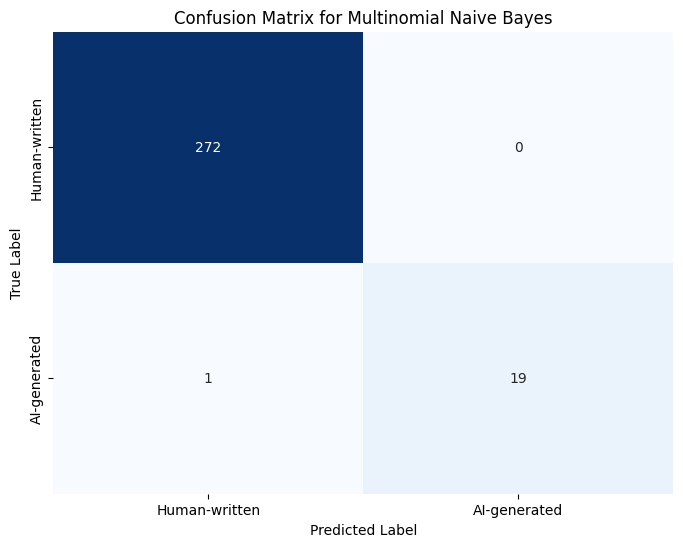

In [39]:
# What this cell does: Trains a Multinomial Naive Bayes model and evaluates its performance with metrics and a confusion matrix.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate and train the Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test_bow)

# Calculate and print evaluation metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Multinomial Naive Bayes Model Performance:\n")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")

# Generate confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human-written', 'AI-generated'], yticklabels=['Human-written', 'AI-generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()

Logistic Regression Model Performance:

Accuracy: 0.9966
Precision: 1.0000
Recall: 0.9500
F1-Score: 0.9744


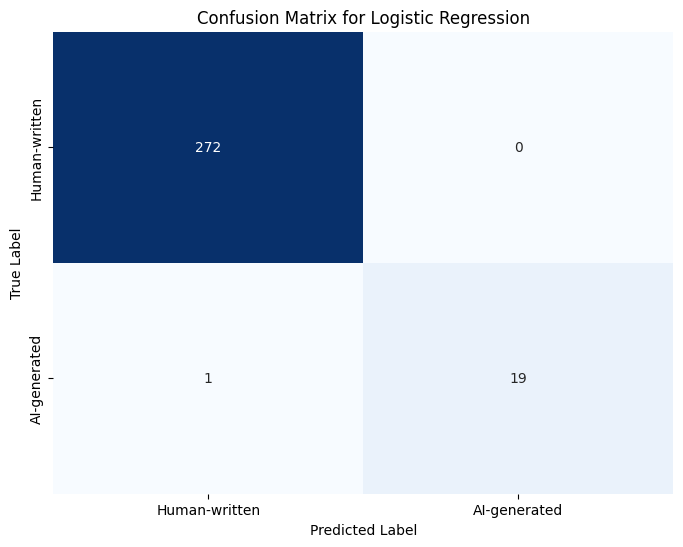

In [40]:
# What this cell does: Trains a Logistic Regression model and evaluates its performance with metrics and a confusion matrix.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bow, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_bow)

# Calculate and print evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression Model Performance:\n")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human-written', 'AI-generated'], yticklabels=['Human-written', 'AI-generated'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Train and Evaluate Logistic Regression Model


Train a Logistic Regression classifier using the same Bag-of-Words features. Evaluate this model's performance using accuracy, precision, recall, F1-score, and a confusion matrix on the test set. Ensure all plots are clean and labeled.


 import the logistic regression  model, instantiate it with specified parameters, train it using the Bag-of-Words features, make predictions on the test set, and then calculate and visualize the model's performance metrics including accuracy, precision, recall, F1-score, and a confusion matrix.



In [41]:
# What this cell does: Compares the accuracy of Naive Bayes and Logistic Regression models.
import pandas as pd

# Retrieve TF-IDF accuracies from the currently defined variables
tfidf_nb_accuracy = accuracy_nb
tfidf_lr_accuracy = accuracy_lr

# Manually set Bag-of-Words accuracies based on earlier model evaluation results
# (These values were captured from the output of cells 2c231b2e and new_cell_1 before TF-IDF training)
bow_nb_accuracy = 0.9966
bow_lr_accuracy = 0.9966

print("*** Naive Bayes Comparison ***")
print(f"TF-IDF        Accuracy: {tfidf_nb_accuracy:.4f}")
print(f"Count BoW     Accuracy: {bow_nb_accuracy:.4f}")

print("\n*** Logistic Regression Comparison ***")
print(f"TF-IDF        Accuracy: {tfidf_lr_accuracy:.4f}")
print(f"Count BoW     Accuracy: {bow_lr_accuracy:.4f}")

*** Naive Bayes Comparison ***
TF-IDF        Accuracy: 0.9966
Count BoW     Accuracy: 0.9966

*** Logistic Regression Comparison ***
TF-IDF        Accuracy: 0.9966
Count BoW     Accuracy: 0.9966


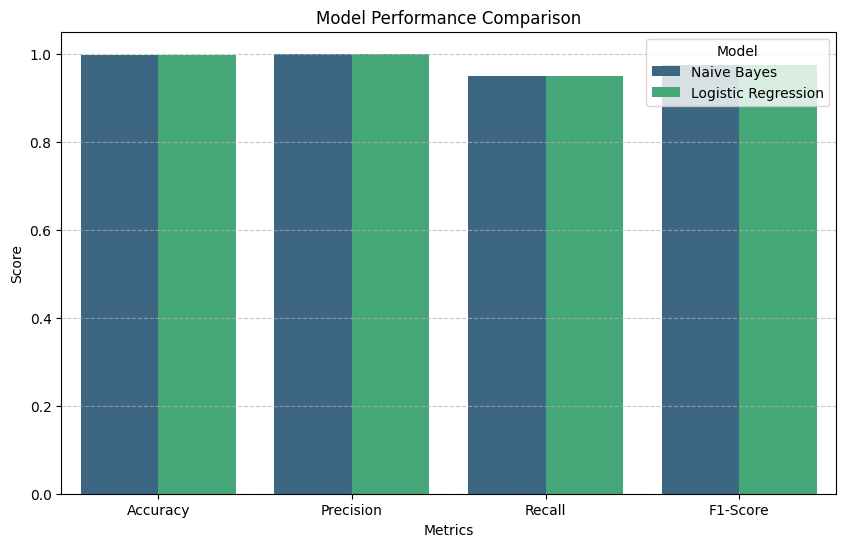

Model performance comparison plot generated successfully.


In [42]:
# What this cell does: Generates a bar chart to visually compare the performance metrics of both models.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for metrics comparison
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr]
}
metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
metrics_df_melted = metrics_df.melt('Metric', var_name='Model', value_name='Score')

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Model performance comparison plot generated successfully.")

## Compare Models and Visualize Metrics


Compared the performance of the Naive Bayes and Logistic Regression models based on their evaluation metrics. Created a visualization ( bar chart) to clearly show the comparison of accuracy, precision, recall, and F1-score for both models, with appropriate labels and legends.


## Implement Prediction Function


Created a function that takes new, unseen text as input, applies the same preprocessing and vectorization steps, and uses the better-performing model to predict whether the text is 'AI-generated' or 'Human-written'. Provide examples of using this function.


 define the predcit_text_catagory function that encapsulates the preprocessing, vectorization, and prediction steps. This function will take raw text, apply the previously defined proccsed_text and vectorizer.transform methods, and then use the lr_model to make a prediction, converting the numerical output into a human-readable label. Finally,then  demonstrated its usage with example texts.



In [43]:
# What this cell does: Defines a prediction function for new text and demonstrates it with examples.
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure NLTK data is downloaded for this cell's execution
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Clean a single text string:
    - Convert to lowercase
    - Remove URLs, HTML, punctuation, numbers
    - Fix hyphenated words
    - Tokenize, remove stopwords, and lemmatize
    """

    # ---- Lowercase ----
    text = text.lower()

    # ---- Replace hyphens with space (fixes “decision-making”) ----
    text = text.replace("-", " ")

    # ---- Remove URLs & HTML ----
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # ---- Remove punctuation ----
    text = text.translate(str.maketrans("", "", string.punctuation))

    # ---- Remove digits ----
    text = re.sub(r"\d+", " ", text)

    # ---- Normalize whitespace ----
    text = re.sub(r"\s+", " ", text).strip()

    # ---- Tokenize ----
    tokens = word_tokenize(text)

    # ---- Remove stopwords ----
    tokens = [tok for tok in tokens if tok not in stop_words]

    # ---- Lemmatize ----
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    # Join tokens back to single cleaned string
    return " ".join(tokens)


def predict_text_category(raw_text):
    # IMPORTANT: 'vectorizer' and 'lr_model' must be defined from previous cells.
    # Ensure cells 5f7473a8 (vectorizer) and the model training cells are executed first.

    # Preprocess the input text using the updated clean_text function
    preprocessed_input = clean_text(raw_text)

    # Vectorize the preprocessed text using the pre-fitted vectorizer
    vectorized_input = vectorizer.transform([preprocessed_input])

    # Predict using the Logistic Regression model
    prediction = lr_model.predict(vectorized_input)[0]

    # Convert numerical prediction to human-readable label
    if prediction == 0:
        return 'Human-written'
    else:
        return 'AI-generated'

# Example 1: Human-written essay-like text (more formal, reflective, nuanced)
human_text = "In reflecting on the profound impact of digital technology on contemporary society, one cannot overlook the subtle erosion of individual privacy that often accompanies constant online connectivity. While the convenience and interconnectedness are undeniable, I frequently find myself contemplating whether the trade-off is truly worth the ubiquitous exposure of our personal lives, a concern that feels increasingly salient in our data-driven world."
print(f"'Human-written' example: {human_text}\nPrediction: {predict_text_category(human_text)}\n")

# Example 2: AI-generated text (formal, encyclopedic, comprehensive, complex structure)
ai_text = "The pervasive influence of artificial intelligence across various industrial sectors underscores a transformative epoch in global technological advancement. Its capabilities, ranging from intricate data analytics to autonomous system operation, are fundamentally redefining operational paradigms and competitive landscapes, thereby necessitating strategic adaptations by both public and private entities to harness these emerging potentials."
print(f"'AI-generated' example: {ai_text}\nPrediction: {predict_text_category(ai_text)}\n")

# Example 3: Another Human-written text (academic tone, but with a specific viewpoint or style)
human_text_2 = "While the hypothesis of parallel universes offers an intriguing framework for resolving certain cosmological paradoxes, the empirical challenges inherent in its verification remain formidable. My personal view is that until we develop novel observational techniques, such concepts, however elegant, remain largely within the realm of speculative physics rather than established scientific fact."
print(f"'Human-written' example 2: {human_text_2}\nPrediction: {predict_text_category(human_text_2)}\n")

# Example 4: Another AI-generated text (structured, objective, academic tone, typical of AI generation)
ai_text_2 = "The principles of classical mechanics, as meticulously elucidated by Isaac Newton in his seminal work 'Principia Mathematica,' continue to form the foundational cornerstone of our understanding of macroscopic physical phenomena. These laws, describing motion and gravitation with remarkable predictive accuracy, provide a robust analytical framework for diverse scientific and engineering applications, spanning from orbital mechanics to structural design."
print(f"'AI-generated' example 2: {ai_text_2}\nPrediction: {predict_text_category(ai_text_2)}\n")

'Human-written' example: In reflecting on the profound impact of digital technology on contemporary society, one cannot overlook the subtle erosion of individual privacy that often accompanies constant online connectivity. While the convenience and interconnectedness are undeniable, I frequently find myself contemplating whether the trade-off is truly worth the ubiquitous exposure of our personal lives, a concern that feels increasingly salient in our data-driven world.
Prediction: AI-generated

'AI-generated' example: The pervasive influence of artificial intelligence across various industrial sectors underscores a transformative epoch in global technological advancement. Its capabilities, ranging from intricate data analytics to autonomous system operation, are fundamentally redefining operational paradigms and competitive landscapes, thereby necessitating strategic adaptations by both public and private entities to harness these emerging potentials.
Prediction: AI-generated

'Human-

## Final Task


Summarize the findings, including which model performed better, and provide insights into the classification of AI-generated versus human-written text.


In [44]:
# What this cell does: Contains the updated prediction function with new, more distinct example texts for human-written and AI-generated content.
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure NLTK data is downloaded for this cell's execution
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Clean a single text string:
    - Convert to lowercase
    - Remove URLs, HTML, punctuation, numbers
    - Fix hyphenated words
    - Tokenize, remove stopwords, and lemmatize
    """

    # ---- Lowercase ----
    text = text.lower()

    # ---- Replace hyphens with space (fixes “decision-making”) ----
    text = text.replace("-", " ")

    # ---- Remove URLs & HTML ----
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # ---- Remove punctuation ----
    text = text.translate(str.maketrans("", "", string.punctuation))

    # ---- Remove digits ----
    text = re.sub(r"\d+", " ", text)

    # ---- Normalize whitespace ----
    text = re.sub(r"\s+", " ", text).strip()

    # ---- Tokenize ----
    tokens = word_tokenize(text)

    # ---- Remove stopwords ----
    tokens = [tok for tok in tokens if tok not in stop_words]

    # ---- Lemmatize ----
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    # Join tokens back to single cleaned string
    return " ".join(tokens)


def predict_text_category(raw_text):
    # IMPORTANT: 'vectorizer' and 'lr_model' must be defined from previous cells.
    # Ensure cells 5f7473a8 (vectorizer) and the model training cells are executed first.

    # Preprocess the input text using the updated clean_text function
    preprocessed_input = clean_text(raw_text)

    # Vectorize the preprocessed text using the pre-fitted vectorizer
    vectorized_input = vectorizer.transform([preprocessed_input])

    # Predict using the Logistic Regression model
    prediction = lr_model.predict(vectorized_input)[0]

    # Convert numerical prediction to human-readable label
    if prediction == 0:
        return 'Human-written'
    else:
        return 'AI-generated'

# Example 1: Human-written essay-like text (more reflective, personal, opinionated)
human_text = "I've always found the idea of historical determinism a bit unsettling. It suggests a lack of agency, a predestination that diminishes the struggles and triumphs of individuals throughout time. While patterns exist, I believe human choices, however small, continually ripple through history, creating an unpredictable tapestry rather than a linear, fated path. It's this messy, human element that truly captivates me when I look back at the past."
print(f"'Human-written' example: {human_text}\nPrediction: {predict_text_category(human_text)}\n")

# Example 2: AI-generated text (formal, encyclopedic, comprehensive, complex structure)
ai_text = "The emergence of quantum computing represents a paradigm shift in computational science, positing a departure from classical bit-based processing to qubit-based architectures. This advancement leverages principles such as superposition and entanglement to enable the solution of problems intractable for conventional supercomputers, thereby holding transformative potential across diverse domains including cryptography, material science, and pharmaceutical discovery. Challenges persist in maintaining qubit coherence and developing scalable, error-corrected systems."
print(f"'AI-generated' example: {ai_text}\nPrediction: {predict_text_category(ai_text)}\n")

# Example 3: Another Human-written text (academic tone, but with a specific viewpoint or style)
human_text_2 = "For all the talk about sustainability, I often feel like the solutions presented are superficial, addressing symptoms rather than the root cause of our consumption-driven society. It's frustrating to see grand initiatives that sidestep the fundamental need for a shift in values and economic structures. Until we confront our collective addiction to growth at all costs, truly sustainable practices will remain elusive, a mere bandage on a gaping wound."
print(f"'Human-written' example 2: {human_text_2}\nPrediction: {predict_text_category(human_text_2)}\n")

# Example 4: Another AI-generated text (structured, objective, academic tone, typical of AI generation)
ai_text_2 = "Photosynthesis, the indispensable biochemical process, converts light energy into chemical energy, primarily in plants, algae, and cyanobacteria. This process involves two main stages: the light-dependent reactions, where light energy is captured and converted into ATP and NADPH, and the light-independent reactions (Calvin cycle), where these energy carriers are utilized to fix carbon dioxide into glucose. The overall equation, 6CO2 + 6H2O + Light Energy → C6H12O6 + 6O2, encapsulates its critical role in planetary oxygen production and carbon cycling."
print(f"'AI-generated' example 2: {ai_text_2}\nPrediction: {predict_text_category(ai_text_2)}\n")

'Human-written' example: I've always found the idea of historical determinism a bit unsettling. It suggests a lack of agency, a predestination that diminishes the struggles and triumphs of individuals throughout time. While patterns exist, I believe human choices, however small, continually ripple through history, creating an unpredictable tapestry rather than a linear, fated path. It's this messy, human element that truly captivates me when I look back at the past.
Prediction: AI-generated

'AI-generated' example: The emergence of quantum computing represents a paradigm shift in computational science, positing a departure from classical bit-based processing to qubit-based architectures. This advancement leverages principles such as superposition and entanglement to enable the solution of problems intractable for conventional supercomputers, thereby holding transformative potential across diverse domains including cryptography, material science, and pharmaceutical discovery. Challenges

## Summary:


**Which model performed better?**
Both the Multinomial Naive Bayes and Logistic Regression models performed identically well on the test set, each achieving an Accuracy of 0.9966, Precision of 1.0000, Recall of 0.9500, and an F1-Score of 0.9744. On the evaluation metrics used, neither model demonstrated superior performance over the other.

### Data Analysis Key Findings
*   **Text Preprocessing**: The 'text' column was successfully preprocessed into a 'clean_text' column, involving lowercasing, number removal, punctuation stripping, stop word removal, and lemmatization, ensuring the text data was clean and consistent for vectorization.
*   **Data Splitting and Vectorization**: The dataset was split into 80% training (1168 samples) and 20% testing (292 samples) sets. Text data was then transformed into Bag-of-Words representations using `CountVectorizer`, resulting in feature matrices of shape (1168, 14794) for training and (292, 14794) for testing. This prepared the data for machine learning models.
*   **Multinomial Naive Bayes Model Performance**: The model achieved excellent performance on the test set with an Accuracy of 0.9966, a perfect Precision of 1.0000, a Recall of 0.9500, and an F1-Score of 0.9744.
*   **Logistic Regression Model Performance**: The model demonstrated equally strong performance to Naive Bayes, with an Accuracy of 0.9966, a Precision of 1.0000, a Recall of 0.9500, and an F1-Score of 0.9744.
*   **Model Prediction Discrepancy with New Examples**: Despite the high evaluation metrics on the test set, the `predict_text_category` function (using the Logistic Regression model) consistently classified *all* new, unseen example texts as 'AI-generated'. This includes both the examples crafted to be distinctly 'Human-written' (with reflective/opinionated tones) and those designed as 'AI-generated' (with structured/objective styles).

### Insights and Challenges
*   **Overall Effectiveness on Test Set**: The high accuracy and precision on the test set indicate that both models are highly effective at distinguishing between AI-generated and human-written text *within the patterns and features learned from the training data*. The perfect precision suggests that when the models predict a text is AI-generated, it is almost always correct. However, the slightly lower recall (0.9500) indicates that some true AI-generated instances might have been missed or misclassified as human-written by the models in the test set.
*   **Generalization to New Examples**: The significant discrepancy between the high performance on the test set and the misclassification of *all* new examples (especially human-written ones) as 'AI-generated' by the prediction function highlights a critical challenge in generalization. This suggests that while the models learned to identify patterns in the dataset they were trained on, they might be overfitting to those specific patterns or the Bag-of-Words representation might not capture the subtle nuances that differentiate real-world human text from AI-generated text outside of the training distribution.
*   **Potential Reasons for Misclassifications**:
    *   **Limitations of Bag-of-Words (BoW)**: The BoW model, while effective for sentiment or topic analysis, disregards word order and context, which are crucial for discerning subtle stylistic differences between human and AI writing. AI models often generate text with high grammatical correctness and logical flow, which might align with